# 16.6.2 固定经验的 Q 更新与独立评估

## 学习目标与先修知识

实现表格 Q 更新，区分训练样本与独立策略评价。

先修：16.6.1 有限 MDP 与策略价值；条件期望（expectation）。

## 具体问题

从一串固定交互中更新 Q 表后，训练期间获得高奖励就能直接宣布策略最优吗？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from systems_science import plot_style
plot_style()
font_names={font.name for font in font_manager.fontManager.ttflist}
for name in ("Microsoft YaHei","SimHei","Noto Sans CJK SC"):
    if name in font_names:
        plt.rcParams["font.sans-serif"]=[name,"DejaVu Sans"]
        break
BLUE,PINK,GREEN="#008bfb","#ff0051","#00a56a"

## 初步实验

先作数值预测，再与完整模型（model）对照。

In [2]:
old=.2;reward=1.;alpha=.5;gamma=.9;best_next=.4;print("一次非终止 Q 更新：",old+alpha*(reward+gamma*best_next-old))

一次非终止 Q 更新： 0.78


## 模型假设

经验列为 [state,action,reward,next_state,done]；按给定顺序原地更新，终止转移的目标只含 reward。学习率与折扣固定；有限固定经验没有“每状态（state）动作无限访问”的收敛前提。

## 数学解释与推导

Q-learning（Q-learning）更新 $Q(s,a)\leftarrow Q(s,a)+\alpha[r+\gamma(1-d)\max_{a'}Q(s',a')-Q(s,a)]$，其中终止标记 $d=1$。它从样本更新动作价值；若经验覆盖不充分，未访问的动作仍保持初值（initial condition）。训练中挑选动作、评估确定策略和比较已知模型规划，需要分别说明信息与预算。原论文收敛结论有反复探索等条件，本节有限序列不满足。

## 核心实现

下面的函数保留计算步骤，可逐行修改并核对。

In [3]:
def q_learning_updates(initial,experience,alpha,gamma):
    Q=np.asarray(initial,dtype=float).copy()
    for state,action,reward,next_state,done in experience:
        target=reward if done else reward+gamma*float(np.max(Q[next_state]))
        Q[state,action]+=alpha*(target-Q[state,action])
    return Q.tolist()


def policy_values(transitions,rewards,policy,gamma):
    P=np.asarray(transitions,dtype=float);R=np.asarray(rewards,dtype=float)
    pi=np.asarray(policy,dtype=int);indices=np.arange(len(pi))
    chosen=P[indices,pi,:];reward=R[indices,pi]
    return np.linalg.solve(np.eye(len(pi))-gamma*chosen,reward).tolist()

## 对照实验

改变已声明的条件并比较曲线与数值。

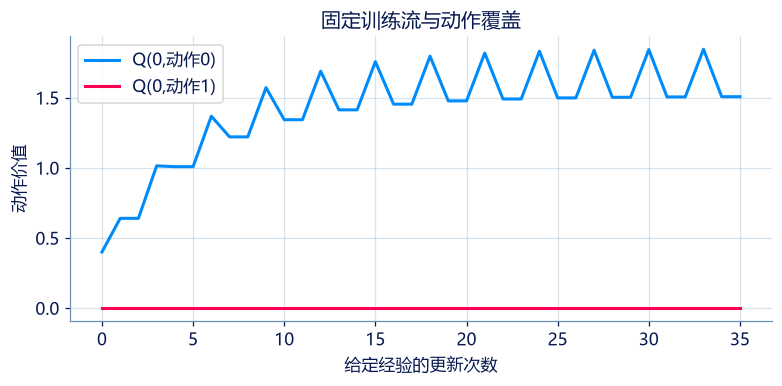

训练后 Q 表： [[1.50742078 0.        ]
 [0.         0.        ]]


In [4]:
experience=[[0,0,1.,0,False],[0,0,1.,1,True],[0,1,0.,1,True]]*12
Q=np.zeros((2,2));trace=[]
for row in experience:
    Q=np.asarray(q_learning_updates(Q,[row],.4,.9));trace.append(Q[0].copy())
trace=np.asarray(trace);fig,ax=plt.subplots(figsize=(7,3.4));ax.plot(trace[:,0],label="Q(0,动作0)",color=BLUE);ax.plot(trace[:,1],label="Q(0,动作1)",color=PINK);ax.set(xlabel="给定经验的更新次数",ylabel="动作价值",title="固定训练流与动作覆盖");ax.legend();ax.grid(alpha=.25);plt.show()
print("训练后 Q 表：",Q)

## 结果解释

这段经验恰好覆盖两个动作，但其频率和转移比例是人为固定的。Q 表变化不能替代在独立场景中评估所得策略；失败回合仍需纳入。

### 独立核对

对本节的核心结果使用解析值、代数恒等式或独立差分核对。

In [5]:
one=q_learning_updates([[0.,0.],[0.,0.]],[[0,0,1.,1,True]],.5,.9)
np.testing.assert_allclose(one,[[.5,0.],[0.,0.]])
assert np.isfinite(Q).all() and trace.shape==(len(experience),2)
print("终止更新、经验条数与表值核验通过。")

终止更新、经验条数与表值核验通过。


[在本章探索中改变条件](http://127.0.0.1:8000/chapters/16-06-%E5%BC%BA%E5%8C%96%E5%AD%A6%E4%B9%A0%E4%B8%8E%E7%AD%96%E7%95%A5%E8%AF%84%E4%BC%B0/explore/)：先预测，再查看结果与简化假设。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · 单项选择题：终止样本的 Q 目标

一次经验标记 done=True，Q 更新目标是什么？

- **A.** r+γmaxQ(next)。
- **B.** 直接设置为0。
- **C.** 仅本步奖励 r。
- **D.** 训练集（training set）平均回报。

[作答：终止样本的 Q 目标](http://127.0.0.1:8000/chapters/16-06-%E5%BC%BA%E5%8C%96%E5%AD%A6%E4%B9%A0%E4%B8%8E%E7%AD%96%E7%95%A5%E8%AF%84%E4%BC%B0/practice/?question=p16-terminal-q)

### 第 2 题 · 单项选择题：有限经验的结论

固定短经验序列更新后 Q 表稳定，能声称原论文的最优收敛定理已适用吗？

- **A.** 能，因为曲线变平。
- **B.** 能，只要学习率非零。
- **C.** 能，只要奖励为正。
- **D.** 不能；需说明覆盖、预算和独立策略评估（policy evaluation）。

[作答：有限经验的结论](http://127.0.0.1:8000/chapters/16-06-%E5%BC%BA%E5%8C%96%E5%AD%A6%E4%B9%A0%E4%B8%8E%E7%AD%96%E7%95%A5%E8%AF%84%E4%BC%B0/practice/?question=p16-finite-q-claim)

### 第 3 题 · Python 计算题：终止经验的 Q 更新

按经验出现顺序做表格 Q 更新；终止样本的目标只含本步奖励。

**函数与代码模板**

```python
def solve(
    initial: list[list[float]],
    experience: list,
    alpha: float,
    gamma: float,
) -> list[list[float]]:
    # 按题给公式完成计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `initial` | `list[list[float]]` | 状态（state）×动作初始 Q 表。 | 奖励 |
| `experience` | `list` | 每行[state,action,reward,next_state,done]。 | 混合 |
| `alpha` | `float` | 学习率。 | 1 |
| `gamma` | `float` | 折扣因子。 | 1 |

**返回值**

直接返回 Q（list[list[float]]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `Q` | `list[list[float]]` | 全部经验后的 Q 表。 | 奖励 |

**计算规则**

按经验顺序更新 Q[s,a]；非终止目标 r+gamma*max_b Q[next,b]，终止目标只有 r。

**约束与边界**

- Q 为2—8状态×1—4动作的有限表；经验长度≤100，索引合法；0<alpha≤1、0≤gamma<1。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| initial | 状态（state）×动作初始 Q 表。 | [[0.0, 0.0], [0.0, 0.0]] | 奖励 |
| experience | 每行[state,action,reward,next_state,done]。 | [[0, 1, 2.0, 1, True]] | 混合 |
| alpha | 学习率。 | 0.5 | 1 |
| gamma | 折扣因子。 | 0.9 | 1 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
initial = [[0.0, 0.0], [0.0, 0.0]]
experience = [[0, 1, 2.0, 1, True]]
alpha = 0.5
gamma = 0.9

result = solve(initial, experience, alpha, gamma)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| Q | 全部经验后的 Q 表。 | [[0.0, 1.0], [0.0, 0.0]] | 奖励 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [[0.0, 1.0], [0.0, 0.0]]
```

**样例解释**

首例目标为2，旧 Q=0、学习率0.5，因此新 Q[0,1]=1。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：终止经验的 Q 更新](http://127.0.0.1:8000/chapters/16-06-%E5%BC%BA%E5%8C%96%E5%AD%A6%E4%B9%A0%E4%B8%8E%E7%AD%96%E7%95%A5%E8%AF%84%E4%BC%B0/practice/?question=p16-q-one-update)

### 第 4 题 · Python 计算题：经验顺序影响有限次更新

按列表顺序逐条更新 Q；后一条可读取前一条已改过的表。

**函数与代码模板**

```python
def solve(
    initial: list[list[float]],
    experience: list,
    alpha: float,
    gamma: float,
) -> list[list[float]]:
    # 按题给公式完成计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `initial` | `list[list[float]]` | 初始 Q 表。 | 奖励 |
| `experience` | `list` | 依次出现的五元组经验。 | 混合 |
| `alpha` | `float` | 学习率。 | 1 |
| `gamma` | `float` | 折扣因子。 | 1 |

**返回值**

直接返回 Q（list[list[float]]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `Q` | `list[list[float]]` | 最终 Q 表。 | 奖励 |

**计算规则**

按经验顺序更新 Q[s,a]；非终止目标 r+gamma*max_b Q[next,b]，终止目标只有 r。

**约束与边界**

- Q 为2—8状态（state）×1—4动作的有限表；经验长度≤100，索引合法；0<alpha≤1、0≤gamma<1。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| initial | 初始 Q 表。 | [[0.0], [0.0]] | 奖励 |
| experience | 依次出现的五元组经验。 | [[1, 0, 2.0, 1, True], [0, 0, 1.0, 1, False]] | 混合 |
| alpha | 学习率。 | 1 | 1 |
| gamma | 折扣因子。 | 0.5 | 1 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
initial = [[0.0], [0.0]]
experience = [[1, 0, 2.0, 1, True], [0, 0, 1.0, 1, False]]
alpha = 1.0
gamma = 0.5

result = solve(initial, experience, alpha, gamma)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| Q | 最终 Q 表。 | [[2.0], [2.0]] | 奖励 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [[2.0], [2.0]]
```

**样例解释**

首例先把 Q[1,0] 更新为2，第二条再用它得到目标1+0.5×2=2。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：经验顺序影响有限次更新](http://127.0.0.1:8000/chapters/16-06-%E5%BC%BA%E5%8C%96%E5%AD%A6%E4%B9%A0%E4%B8%8E%E7%AD%96%E7%95%A5%E8%AF%84%E4%BC%B0/practice/?question=p16-q-sequential)

**进一步阅读**

[Watkins 与 Dayan 1992](https://www.gatsby.ucl.ac.uk/~dayan/papers/cjch.pdf)的收敛条件比本节有限经验严格。